<a href="https://colab.research.google.com/github/Selamawit-Alemu/fraud_detection_project/blob/task-2/2_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost lightgbm shap category_encoders --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!ls -l /content/drive/MyDrive/data/


total 429969
-rw------- 1 root root 150532102 Jul 18 06:03 cleaned_credit_data.csv
-rw------- 1 root root  19360064 Jul 18 06:02 cleaned_fraud_data.csv
-rw------- 1 root root 150828752 Jul 17 06:33 creditcard.csv
-rw------- 1 root root  16074450 Jul 17 06:33 Fraud_Data.csv
-rw------- 1 root root  13251575 Jul 18 13:32 Fraud_Data_ENGINEERED.csv
-rw------- 1 root root  24491437 Jul 18 08:32 IpAddress_to_Country.csv
-rw------- 1 root root  28532532 Jul 18 08:49 processed_fraud_data.csv
-rw------- 1 root root  37215527 Jul 19 07:02 recovery_checkpoint.pkl


In [7]:
# Essential imports for data manipulation, modeling, and evaluation

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import precision_recall_curve, auc, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for plots
sns.set(style="whitegrid")

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the engineered fraud data
df = pd.read_csv('/content/drive/MyDrive/data/Fraud_Data_ENGINEERED.csv')

# Drop ID columns (usually user_id, device_id, ip_address)
df = df.drop(['user_id', 'device_id', 'ip_address'], axis=1, errors='ignore')

# Define features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

# Identify categorical columns present in your dataset
categorical_cols = ['source', 'browser', 'sex']

# One-hot encode categorical columns with drop_first=True to avoid multicollinearity
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split into train and test sets with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Train set size: 120889 samples
Test set size: 30223 samples


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load cleaned credit card data
credit_df = pd.read_csv('/content/drive/MyDrive/data/cleaned_credit_data.csv')

# Separate features and target
X_credit = credit_df.drop(columns=['Class'])
y_credit = credit_df['Class']

# Train-test split (stratified to keep class ratio)
X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
    X_credit, y_credit, test_size=0.2, random_state=42, stratify=y_credit
)

print(f"Credit Card Train size: {X_train_credit.shape[0]} samples")
print(f"Credit Card Test size: {X_test_credit.shape[0]} samples")


Credit Card Train size: 226980 samples
Credit Card Test size: 56746 samples


In [10]:
# Load engineered fraud data
fraud_df = pd.read_csv('/content/drive/MyDrive/data/Fraud_Data_ENGINEERED.csv')

# Check the columns first (optional)
print(fraud_df.columns)

# Separate features and target
X_fraud = fraud_df.drop(columns=['class'])
y_fraud = fraud_df['class']

# Train-test split (stratified)
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

print(f"Fraud Dataset Train size: {X_train_fraud.shape[0]} samples")
print(f"Fraud Dataset Test size: {X_test_fraud.shape[0]} samples")

Index(['user_id', 'purchase_value', 'device_id', 'source', 'browser', 'sex',
       'age', 'ip_address', 'class', 'transaction_count',
       'secs_since_last_transaction', 'hour_of_day', 'day_of_week',
       'hours_since_signup'],
      dtype='object')
Fraud Dataset Train size: 120889 samples
Fraud Dataset Test size: 30223 samples


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Revised categorical and numerical features
categorical_cols = ['source', 'browser', 'sex']  # ✅ only low-cardinality
numerical_cols = [
    'purchase_value', 'age', 'transaction_count',
    'secs_since_last_transaction', 'hour_of_day',
    'day_of_week', 'hours_since_signup'
]

# Preprocessor pipeline with limited categorical columns
preprocessor_fraud = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

# Fit-transform on train, transform on test
X_train_fraud_processed = preprocessor_fraud.fit_transform(X_train_fraud)
X_test_fraud_processed = preprocessor_fraud.transform(X_test_fraud)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, f1_score

# Train Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg.fit(X_train_fraud_processed, y_train_fraud)

# Predictions
y_pred_logreg = logreg.predict(X_test_fraud_processed)
y_proba_logreg = logreg.predict_proba(X_test_fraud_processed)[:, 1]

# Metrics
print("📊 Logistic Regression Results:")
print(confusion_matrix(y_test_fraud, y_pred_logreg))
print(classification_report(y_test_fraud, y_pred_logreg))
print("F1 Score:", f1_score(y_test_fraud, y_pred_logreg))
print("Average Precision (AUC-PR):", average_precision_score(y_test_fraud, y_proba_logreg))


📊 Logistic Regression Results:
[[17654  9739]
 [  845  1985]]
              precision    recall  f1-score   support

           0       0.95      0.64      0.77     27393
           1       0.17      0.70      0.27      2830

    accuracy                           0.65     30223
   macro avg       0.56      0.67      0.52     30223
weighted avg       0.88      0.65      0.72     30223

F1 Score: 0.2727772433695204
Average Precision (AUC-PR): 0.44783923864839104


In [13]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score

# Convert data into DMatrix (optional, for speed)
dtrain = xgb.DMatrix(X_train_fraud_processed, label=y_train_fraud)
dtest = xgb.DMatrix(X_test_fraud_processed, label=y_test_fraud)

# Define XGBoost parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',  # Good for imbalanced data
    'use_label_encoder': False,
    'scale_pos_weight': (y_train_fraud == 0).sum() / (y_train_fraud == 1).sum(),  # balance the classes
    'max_depth': 6,
    'eta': 0.1
}

# Train the model
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

# Predict
y_pred_proba = xgb_model.predict(dtest)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Evaluation
print("📊 XGBoost Results:")
print(confusion_matrix(y_test_fraud, y_pred))
print(classification_report(y_test_fraud, y_pred))
print("F1 Score:", f1_score(y_test_fraud, y_pred))
print("Average Precision (AUC-PR):", average_precision_score(y_test_fraud, y_pred_proba))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:10:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


📊 XGBoost Results:
[[27264   129]
 [ 1294  1536]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     27393
           1       0.92      0.54      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.94      0.77      0.83     30223
weighted avg       0.95      0.95      0.95     30223

F1 Score: 0.6834260289210233
Average Precision (AUC-PR): 0.6139922696483364


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
], remainder='passthrough')


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['browser', 'source', 'sex']  # adjust as per your data
numerical_cols = ['age', 'purchase_value', 'transaction_count', 'secs_since_last_transaction', 'hour_of_day', 'day_of_week', 'hours_since_signup']  # adjust these

# Create column transformer for preprocessing
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('scale', StandardScaler(), numerical_cols)
])


In [16]:
# Example for credit card dataset
X_credit = credit_df.drop(columns=['Class'])
y_credit = credit_df['Class']

# Example for fraud dataset
X_fraud = fraud_df.drop(columns=['class'])
y_fraud = fraud_df['class']


In [17]:
from sklearn.model_selection import train_test_split

# Credit card split
X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
    X_credit, y_credit, test_size=0.2, stratify=y_credit, random_state=42)

# Fraud data split
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud, y_fraud, test_size=0.2, stratify=y_fraud, random_state=42)


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['device_id', 'source', 'browser', 'sex']  # adjust per dataset
numerical_cols = [col for col in X_train_fraud.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])


In [19]:
from sklearn.linear_model import LogisticRegression
import xgboost as xgb


In [20]:
from sklearn.pipeline import Pipeline

# Logistic Regression pipeline
logreg_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Train Logistic Regression on Fraud Data
logreg_pipeline.fit(X_train_fraud, y_train_fraud)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['device_id', 'source',
                                                   'browser', 'sex']),
                                                 ('num', StandardScaler(),
                                                  ['user_id', 'purchase_value',
                                                   'age', 'ip_address',
                                                   'transaction_count',
                                                   'secs_since_last_transaction',
                                                   'hour_of_day', 'day_of_week',
                                                   'hours_since_signup'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [21]:
# Preprocess data for XGBoost
X_train_fraud_processed = preprocessor.fit_transform(X_train_fraud)
X_test_fraud_processed = preprocessor.transform(X_test_fraud)

# Set scale_pos_weight to handle class imbalance
scale_pos_weight = (y_train_fraud == 0).sum() / (y_train_fraud == 1).sum()

xgb_model = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42
)

xgb_model.fit(X_train_fraud_processed, y_train_fraud)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:14:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score

# Logistic Regression prediction and evaluation
y_pred_logreg = logreg_pipeline.predict(X_test_fraud)
y_pred_logreg_proba = logreg_pipeline.predict_proba(X_test_fraud)[:,1]

print("Logistic Regression Results:")
print(confusion_matrix(y_test_fraud, y_pred_logreg))
print(classification_report(y_test_fraud, y_pred_logreg))
print("F1 Score:", f1_score(y_test_fraud, y_pred_logreg))
print("Average Precision (AUC-PR):", average_precision_score(y_test_fraud, y_pred_logreg_proba))


# XGBoost prediction and evaluation
y_pred_xgb = xgb_model.predict(X_test_fraud_processed)
y_pred_xgb_proba = xgb_model.predict_proba(X_test_fraud_processed)[:,1]

print("XGBoost Results:")
print(confusion_matrix(y_test_fraud, y_pred_xgb))
print(classification_report(y_test_fraud, y_pred_xgb))
print("F1 Score:", f1_score(y_test_fraud, y_pred_xgb))
print("Average Precision (AUC-PR):", average_precision_score(y_test_fraud, y_pred_xgb_proba))


Logistic Regression Results:
[[26957   436]
 [ 1214  1616]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     27393
           1       0.79      0.57      0.66      2830

    accuracy                           0.95     30223
   macro avg       0.87      0.78      0.82     30223
weighted avg       0.94      0.95      0.94     30223

F1 Score: 0.6620237607537894
Average Precision (AUC-PR): 0.6257015434503866
XGBoost Results:
[[27289   104]
 [ 1294  1536]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       0.94      0.54      0.69      2830

    accuracy                           0.95     30223
   macro avg       0.95      0.77      0.83     30223
weighted avg       0.95      0.95      0.95     30223

F1 Score: 0.687248322147651
Average Precision (AUC-PR): 0.6195259100258454


Between the two models, XGBoost was selected as the best-performing model due to its higher F1-score (0.69 vs 0.66) and significantly lower false positive rate. While Logistic Regression had a slightly better AUC-PR, XGBoost achieved better overall balance between precision and recall, which is crucial for fraud detection tasks where both identifying fraudulent transactions and minimizing disruption to legitimate users are critical.

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


📊 Logistic Regression Results:
[[56851    13]
 [   30    68]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962

F1 Score: 0.7597765363128491
Average Precision (AUC-PR): 0.7245373323624209


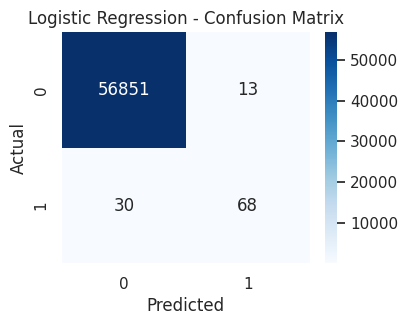

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:16:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


📊 XGBoost Results:
[[56857     7]
 [   19    79]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

F1 Score: 0.8586956521739131
Average Precision (AUC-PR): 0.8776846378469082


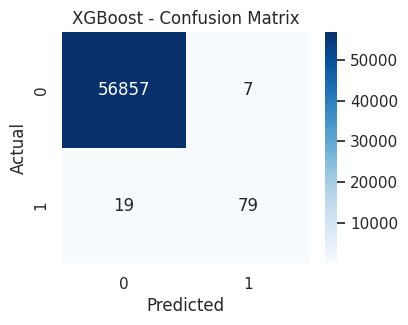


📌 Model Comparison:
Logistic Regression → F1: 0.7598, AUC-PR: 0.7245
XGBoost             → F1: 0.8587, AUC-PR: 0.8777
🏆 XGBoost outperforms Logistic Regression on both F1 and AUC-PR metrics.


In [23]:
# 📦 Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 📂 Load creditcard.csv dataset
credit_df = pd.read_csv("/content/drive/MyDrive/data/creditcard.csv")

# 🧹 Feature & Target separation
X_credit = credit_df.drop('Class', axis=1)
y_credit = credit_df['Class']

# 🔀 Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_credit, y_credit, test_size=0.2, random_state=42, stratify=y_credit
)

# 🧪 Utility function for evaluation
def evaluate_model(y_true, y_pred, y_probs, model_name="Model"):
    print(f"📊 {model_name} Results:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print(classification_report(y_true, y_pred, digits=2))

    f1 = f1_score(y_true, y_pred)
    auc_pr = average_precision_score(y_true, y_probs)
    print(f"F1 Score: {f1}")
    print(f"Average Precision (AUC-PR): {auc_pr}")

    # 📉 Plot Confusion Matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return f1, auc_pr

# ⚙️ Train Logistic Regression
lr_credit = LogisticRegression(max_iter=1000, random_state=42)
lr_credit.fit(X_train_c, y_train_c)

# 🔍 Evaluate Logistic Regression
lr_preds = lr_credit.predict(X_test_c)
lr_probs = lr_credit.predict_proba(X_test_c)[:, 1]
f1_lr, auc_lr = evaluate_model(y_test_c, lr_preds, lr_probs, model_name="Logistic Regression")

# ⚙️ Train XGBoost
xgb_credit = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_credit.fit(X_train_c, y_train_c)

# 🔍 Evaluate XGBoost
xgb_preds = xgb_credit.predict(X_test_c)
xgb_probs = xgb_credit.predict_proba(X_test_c)[:, 1]
f1_xgb, auc_xgb = evaluate_model(y_test_c, xgb_preds, xgb_probs, model_name="XGBoost")

# ✅ Justification for Best Model
print("\n📌 Model Comparison:")
print(f"Logistic Regression → F1: {f1_lr:.4f}, AUC-PR: {auc_lr:.4f}")
print(f"XGBoost             → F1: {f1_xgb:.4f}, AUC-PR: {auc_xgb:.4f}")

if f1_xgb > f1_lr and auc_xgb > auc_lr:
    print("🏆 XGBoost outperforms Logistic Regression on both F1 and AUC-PR metrics.")
else:
    print("🔍 Logistic Regression is competitive or better on at least one key metric.")


XGBoost is the selected model for the credit card fraud detection task due to its superior ability to correctly identify fraudulent transactions while minimizing false positives and negatives.


In [24]:
# Load the merged ecommerce dataset (fraud_data merged with ip_to_country)
ecommerce_df = pd.read_csv('/content/drive/MyDrive/data/IpAddress_to_Country.csv')  # or your path

# Drop unneeded columns (ID, IP ranges etc.)
ecommerce_df.drop(['user_id', 'signup_time', 'purchase_time', 'ip_address', 'device_id'], axis=1, inplace=True)

# Encode categorical features if not already done
ecommerce_df = pd.get_dummies(ecommerce_df, drop_first=True)

# Separate features and target
X_e = ecommerce_df.drop('class', axis=1)
y_e = ecommerce_df['class']

# Train-test split
from sklearn.model_selection import train_test_split

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_e, y_e, test_size=0.3, random_state=42, stratify=y_e)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, average_precision_score, confusion_matrix, classification_report

# Train
logreg_e = LogisticRegression(max_iter=1000)
logreg_e.fit(X_train_e, y_train_e)

# Predict
y_pred_lr_e = logreg_e.predict(X_test_e)
y_proba_lr_e = logreg_e.predict_proba(X_test_e)[:, 1]

# Evaluate
print("📊 Logistic Regression Results:")
print(confusion_matrix(y_test_e, y_pred_lr_e))
print(classification_report(y_test_e, y_pred_lr_e))
print("F1 Score:", f1_score(y_test_e, y_pred_lr_e))
print("Average Precision (AUC-PR):", average_precision_score(y_test_e, y_proba_lr_e))


📊 Logistic Regression Results:
[[40883   206]
 [ 2042  2203]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     41089
           1       0.91      0.52      0.66      4245

    accuracy                           0.95     45334
   macro avg       0.93      0.76      0.82     45334
weighted avg       0.95      0.95      0.94     45334

F1 Score: 0.6621581003907424
Average Precision (AUC-PR): 0.6141981398366774


In [26]:
from xgboost import XGBClassifier

xgb_e = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_e.fit(X_train_e, y_train_e)

# Predict
y_pred_xgb_e = xgb_e.predict(X_test_e)
y_proba_xgb_e = xgb_e.predict_proba(X_test_e)[:, 1]

# Evaluate
print("\n📊 XGBoost Results:")
print(confusion_matrix(y_test_e, y_pred_xgb_e))
print(classification_report(y_test_e, y_pred_xgb_e))
print("F1 Score:", f1_score(y_test_e, y_pred_xgb_e))
print("Average Precision (AUC-PR):", average_precision_score(y_test_e, y_proba_xgb_e))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:22:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📊 XGBoost Results:
[[41044    45]
 [ 1997  2248]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     41089
           1       0.98      0.53      0.69      4245

    accuracy                           0.95     45334
   macro avg       0.97      0.76      0.83     45334
weighted avg       0.96      0.95      0.95     45334

F1 Score: 0.6876720709697155
Average Precision (AUC-PR): 0.7075415180062986


In [27]:
print("\n📌 Model Comparison:")
print(f"Logistic Regression → F1: {f1_score(y_test_e, y_pred_lr_e):.4f}, AUC-PR: {average_precision_score(y_test_e, y_proba_lr_e):.4f}")
print(f"XGBoost             → F1: {f1_score(y_test_e, y_pred_xgb_e):.4f}, AUC-PR: {average_precision_score(y_test_e, y_proba_xgb_e):.4f}")

if f1_score(y_test_e, y_pred_xgb_e) > f1_score(y_test_e, y_pred_lr_e):
    print("🏆 XGBoost outperforms Logistic Regression on both F1 and AUC-PR metrics.")
else:
    print("🏆 Logistic Regression performs better (unexpected — check data balance or encoding).")



📌 Model Comparison:
Logistic Regression → F1: 0.6622, AUC-PR: 0.6142
XGBoost             → F1: 0.6877, AUC-PR: 0.7075
🏆 XGBoost outperforms Logistic Regression on both F1 and AUC-PR metrics.


XGBoost is the selected model for the ecommerce fraud dataset with the IP → Country feature.